# Notebook 2: Exploratory Data Analysis and Data Cleaning

This notebook explores the Olist dataset, checks for data quality issues, and builds a customer-level analytical dataset.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

In [2]:
customers = pd.read_csv(
    RAW_DATA_DIR / "olist_customers_dataset.csv"
)

orders = pd.read_csv(
    RAW_DATA_DIR / "olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    RAW_DATA_DIR / "olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    RAW_DATA_DIR / "olist_order_payments_dataset.csv"
)

products = pd.read_csv(
    RAW_DATA_DIR / "olist_products_dataset.csv"
)

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    print("-" * 50)

customers
(99441, 5)
--------------------------------------------------
orders
(99441, 8)
--------------------------------------------------
order_items
(112650, 7)
--------------------------------------------------
payments
(103886, 5)
--------------------------------------------------
products
(32951, 9)
--------------------------------------------------


### 1. Basic Dataset Overview

In [21]:
# Check the shape of each table

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)


In [22]:
# Preview each dataset

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("=" * 60)
    display(df.head())

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### 2. Missing Values

In [23]:
# Calculate missing value percentages for each dataset

for name, df in datasets.items():
    missing_pct = (
        df.isnull()
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print("\n")
    print(name.upper())
    display(missing_pct[missing_pct > 0])



CUSTOMERS


Series([], dtype: float64)



ORDERS


order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64



ORDER_ITEMS


Series([], dtype: float64)



PAYMENTS


Series([], dtype: float64)



PRODUCTS


product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

### 3. Duplicate Records

In [24]:
# Check duplicate rows in each dataset

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
products: 0 duplicate rows


### 4. Convert Date Columns

In [25]:
# Convert order-related date columns to datetime format

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

### 5. Order Behavior

In [26]:
# Check order status distribution

orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

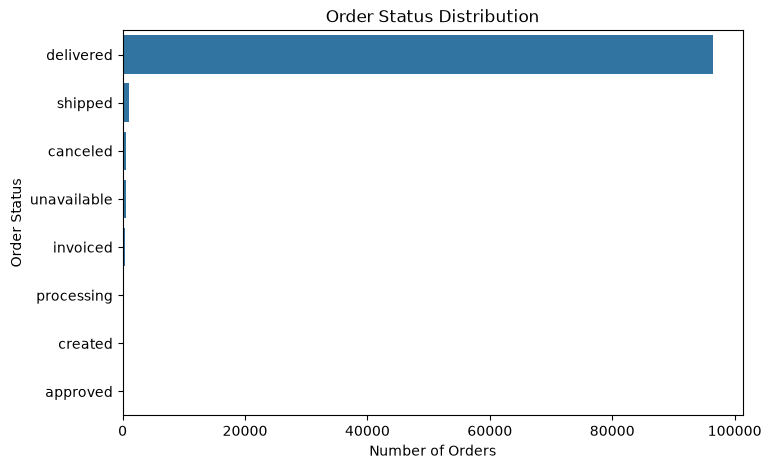

In [27]:
# Visualize order status distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    y="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.show()

In [29]:
# Create monthly order trend

monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
    .reset_index(name="order_count")
)

monthly_orders.head()

,order_purchase_timestamp,order_count
0,2016-09-30,4
1,2016-10-31,324
2,2016-11-30,0
3,2016-12-31,1
4,2017-01-31,800


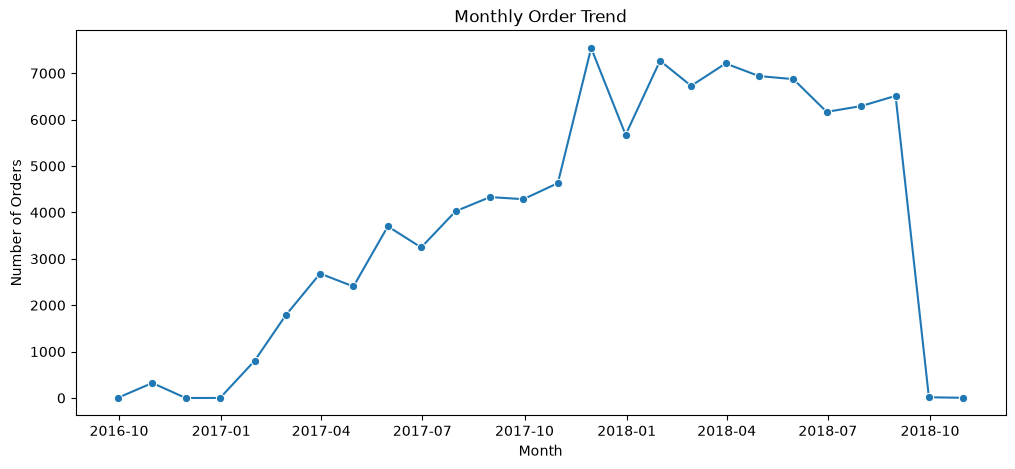

In [30]:
# Plot monthly order trend

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

In [31]:
# Create calendar-style order activity table by day of week and month

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["order_day_of_week"] = orders["order_purchase_timestamp"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

calendar_orders = (
    orders
    .groupby(["order_month", "order_day_of_week"])
    .size()
    .reset_index(name="order_count")
)

calendar_pivot = calendar_orders.pivot(
    index="order_day_of_week",
    columns="order_month",
    values="order_count"
).reindex(day_order)

calendar_pivot.head()

order_month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10
order_day_of_week,,,,,,,,,,,,,,,,,,,,,,,,,
Monday,1.0,47.0,NaN,116.0,269.0,446.0,339.0,706.0,501.0,739.0,648.0,649.0,841.0,1031.0,903.0,1234.0,1047.0,1071.0,1340.0,1085.0,1006.0,1183.0,987.0,6.0,1.0
Tuesday,1.0,63.0,NaN,148.0,284.0,381.0,356.0,639.0,495.0,635.0,780.0,697.0,909.0,960.0,886.0,1278.0,1079.0,1040.0,985.0,1287.0,920.0,1164.0,973.0,2.0,1.0
Wednesday,NaN,47.0,NaN,108.0,293.0,465.0,381.0,631.0,415.0,575.0,768.0,657.0,650.0,996.0,836.0,1284.0,1122.0,964.0,1095.0,1269.0,918.0,958.0,1116.0,2.0,2.0
Thursday,1.0,51.0,NaN,160.0,260.0,456.0,334.0,468.0,571.0,557.0,740.0,558.0,603.0,1091.0,718.0,998.0,1024.0,1249.0,1068.0,1059.0,912.0,819.0,1059.0,5.0,NaN
Friday,NaN,46.0,1.0,107.0,236.0,376.0,305.0,450.0,534.0,517.0,553.0,683.0,541.0,1681.0,932.0,917.0,877.0,1108.0,830.0,852.0,921.0,728.0,927.0,NaN,NaN


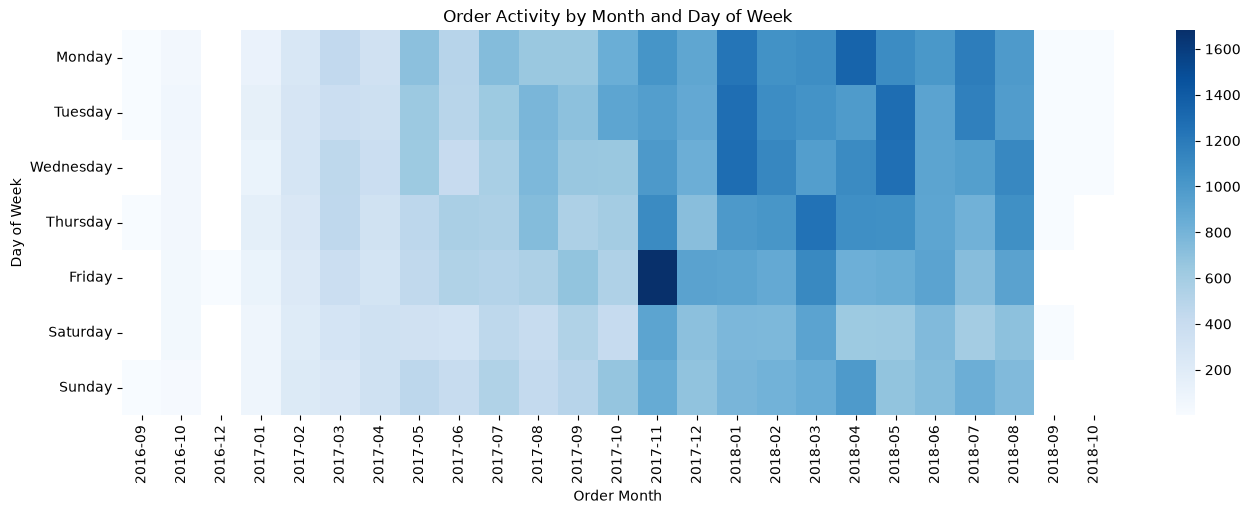

In [32]:
# Heatmap of orders by month and day of week

plt.figure(figsize=(16, 5))

sns.heatmap(
    calendar_pivot,
    cmap="Blues"
)

plt.title("Order Activity by Month and Day of Week")
plt.xlabel("Order Month")
plt.ylabel("Day of Week")

plt.show()

### 6. Payment Analysis

In [33]:
# Summary statistics for payment value

payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

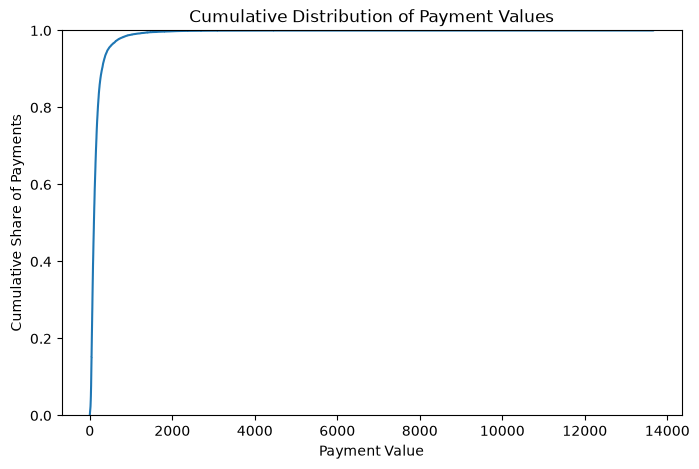

In [34]:
# ECDF plot shows the cumulative distribution of payment values

plt.figure(figsize=(8, 5))

sns.ecdfplot(
    data=payments,
    x="payment_value"
)

plt.title("Cumulative Distribution of Payment Values")
plt.xlabel("Payment Value")
plt.ylabel("Cumulative Share of Payments")

plt.show()

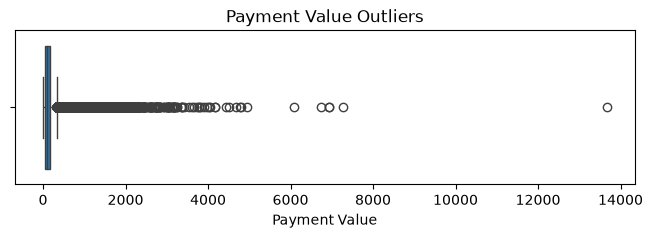

In [35]:
# Boxplot to identify outliers

plt.figure(figsize=(8, 2))

sns.boxplot(
    data=payments,
    x="payment_value"
)

plt.title("Payment Value Outliers")
plt.xlabel("Payment Value")

plt.show()

In [36]:
# Payment type distribution

payment_type_share = (
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

payment_type_share.columns = ["payment_type", "percentage"]

payment_type_share

,payment_type,percentage
0,credit_card,73.922376
1,boleto,19.043952
2,voucher,5.558978
3,debit_card,1.471806
4,not_defined,0.002888


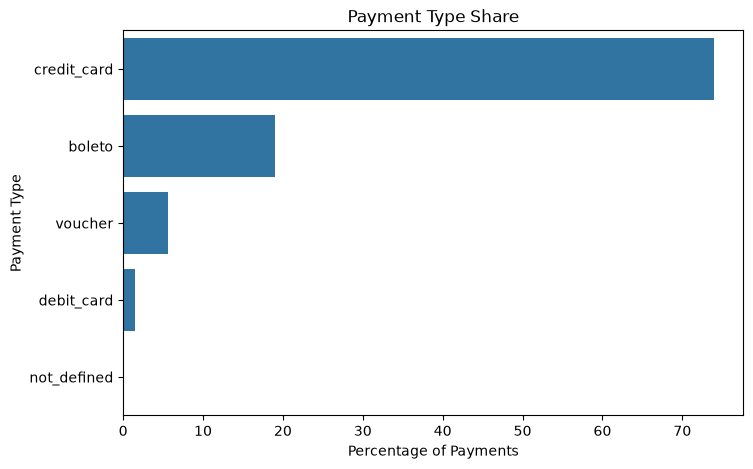

In [37]:
# Visualize payment type share

plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_type_share,
    x="percentage",
    y="payment_type"
)

plt.title("Payment Type Share")
plt.xlabel("Percentage of Payments")
plt.ylabel("Payment Type")

plt.show()